# Climate-Informed Country Embedding for Migration Estimation

This notebook generates contextually informed embeddings for country ISO3 codes based on climate migration features from World Bank indicators rather than random initialization.

In [23]:
import requests
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
WORLD_BANK_API = "https://api.worldbank.org/v2/country/all/indicator"
INDICATORS = {
    "gdp_pc": "NY.GDP.PCAP.PP.KD",
    "agri_gdp": "NV.AGR.TOTL.ZS",
    "rural_pop": "SP.RUR.TOTL.ZS",
    "pop_density": "EN.POP.DNST",
    "electricity": "EG.ELC.ACCS.ZS",
    "school_enroll": "SE.SEC.ENRR",
}
YEAR_RANGE = (2015, 2023)

# Region mapping for visualization (comprehensive and non-overlapping)
REGION_MAP = {
    # Africa
    'AGO': 'Africa', 'BWA': 'Africa', 'CMR': 'Africa', 'COD': 'Africa', 'COG': 'Africa',
    'CIV': 'Africa', 'DZA': 'Africa', 'EGY': 'Africa', 'ETH': 'Africa', 'GAB': 'Africa', 
    'GHA': 'Africa', 'GIN': 'Africa', 'GMB': 'Africa', 'KEN': 'Africa', 'LBR': 'Africa',
    'MAR': 'Africa', 'MLI': 'Africa', 'MOZ': 'Africa', 'MWI': 'Africa', 'NAM': 'Africa',
    'NGA': 'Africa', 'RWA': 'Africa', 'SEN': 'Africa', 'SOM': 'Africa', 'ZAF': 'Africa',
    'TZA': 'Africa', 'TGO': 'Africa', 'TUN': 'Africa', 'UGA': 'Africa', 'ZMB': 'Africa', 'ZWE': 'Africa',
    # Americas
    'ARG': 'Americas', 'BOL': 'Americas', 'BRA': 'Americas', 'CAN': 'Americas', 'CHL': 'Americas',
    'COL': 'Americas', 'CRI': 'Americas', 'CUB': 'Americas', 'DOM': 'Americas', 'ECU': 'Americas',
    'SLV': 'Americas', 'GTM': 'Americas', 'GUY': 'Americas', 'HTI': 'Americas', 'HND': 'Americas',
    'JAM': 'Americas', 'MEX': 'Americas', 'NIC': 'Americas', 'PAN': 'Americas', 'PRY': 'Americas',
    'PER': 'Americas', 'URY': 'Americas', 'VEN': 'Americas', 'USA': 'Americas', 'BRB': 'Americas',
    # Asia
    'AFG': 'Asia', 'BGD': 'Asia', 'BTN': 'Asia', 'KHM': 'Asia', 'CHN': 'Asia', 'IND': 'Asia',
    'IDN': 'Asia', 'JPN': 'Asia', 'KAZ': 'Asia', 'KOR': 'Asia', 'KGZ': 'Asia',
    'LAO': 'Asia', 'MYS': 'Asia', 'MDV': 'Asia', 'MNG': 'Asia', 'MMR': 'Asia',
    'NPL': 'Asia', 'PAK': 'Asia', 'PHL': 'Asia', 'SGP': 'Asia', 'LKA': 'Asia',
    'THA': 'Asia', 'TLS': 'Asia', 'TJK': 'Asia', 'TKM': 'Asia', 'UZB': 'Asia', 'VNM': 'Asia',
    'HKG': 'Asia', 'MAC': 'Asia', 'TWN': 'Asia',
    # Europe
    'ALB': 'Europe', 'AND': 'Europe', 'AUT': 'Europe', 'BLR': 'Europe', 'BEL': 'Europe',
    'BIH': 'Europe', 'BGR': 'Europe', 'HRV': 'Europe', 'CYP': 'Europe', 'CZE': 'Europe',
    'DNK': 'Europe', 'EST': 'Europe', 'FIN': 'Europe', 'FRA': 'Europe', 'DEU': 'Europe',
    'GRC': 'Europe', 'HUN': 'Europe', 'ISL': 'Europe', 'IRL': 'Europe', 'ITA': 'Europe',
    'XKX': 'Europe', 'LVA': 'Europe', 'LIE': 'Europe', 'LTU': 'Europe', 'LUX': 'Europe',
    'MKD': 'Europe', 'MLT': 'Europe', 'MDA': 'Europe', 'MCO': 'Europe', 'MNE': 'Europe',
    'NLD': 'Europe', 'NOR': 'Europe', 'POL': 'Europe', 'PRT': 'Europe', 'ROU': 'Europe',
    'RUS': 'Europe', 'SMR': 'Europe', 'SRB': 'Europe', 'SVK': 'Europe', 'SVN': 'Europe',
    'ESP': 'Europe', 'SWE': 'Europe', 'CHE': 'Europe', 'UKR': 'Europe', 'GBR': 'Europe',
    # Middle East & North Africa  
    'BHR': 'MENA', 'IRN': 'MENA', 'IRQ': 'MENA',
    'ISR': 'MENA', 'JOR': 'MENA', 'KWT': 'MENA', 'LBN': 'MENA', 'LBY': 'MENA',
    'OMN': 'MENA', 'QAT': 'MENA', 'SAU': 'MENA', 'SYR': 'MENA',
    'TUR': 'MENA', 'ARE': 'MENA', 'YEM': 'MENA',
    # Oceania
    'AUS': 'Oceania', 'FJI': 'Oceania', 'KIR': 'Oceania', 'MHL': 'Oceania',
    'FSM': 'Oceania', 'NRU': 'Oceania', 'NZL': 'Oceania', 'PLW': 'Oceania',
    'PNG': 'Oceania', 'WSM': 'Oceania', 'SLB': 'Oceania', 'TON': 'Oceania', 'TUV': 'Oceania', 'VUT': 'Oceania',
}


def fetch_world_bank_indicator(indicator_code):
    """Fetch World Bank indicator data for all countries and years."""
    response = requests.get(f"{WORLD_BANK_API}/{indicator_code}", 
                           params={"format": "json", "per_page": 20000})
    data = response.json()[1]
    
    records = [(d["country"]["id"], int(d["date"]), d["value"]) 
               for d in data if d["value"] is not None]
    
    return pd.DataFrame(records, columns=["country", "year", indicator_code])


def build_climate_dataset(indicators=INDICATORS, year_range=YEAR_RANGE):
    """Build climate indicator dataset by aggregating World Bank data."""
    years = list(range(year_range[0], year_range[1]))
    dfs = []
    
    for name, code in indicators.items():
        df = fetch_world_bank_indicator(code)
        df = df[df["year"].isin(years)].groupby("country")[code].mean().rename(name)
        dfs.append(df)
    
    return pd.concat(dfs, axis=1)


def compute_embeddings(data, n_components=6):
    """Compute PCA embeddings from climate indicators."""
    # Impute missing values with median
    X = SimpleImputer(strategy="median").fit_transform(data)
    # Standardize features
    X = StandardScaler().fit_transform(X)
    # Compute PCA embeddings
    embeddings = PCA(n_components=n_components).fit_transform(X)
    
    return pd.DataFrame(embeddings, index=data.index,
                       columns=[f"emb_{i}" for i in range(n_components)])


def add_region_labels(embeddings, region_map=REGION_MAP):
    """Add region labels to embeddings for visualization."""
    embeddings["region"] = embeddings.index.map(
        lambda x: region_map.get(x, "Other")
    )
    return embeddings

In [30]:
# show example of the dataset
df = build_climate_dataset()
df.head()

,gdp_pc,agri_gdp,rural_pop,pop_density,electricity,school_enroll
country,,,,,,
1A,16479.404137,5.030264,41.148465,33.629119,89.768513,67.340588
1W,19080.570503,4.183605,44.144053,59.494135,89.610536,75.987782
4E,16107.303466,8.086820,42.152011,131.425474,97.424828,87.104267
7E,20454.058992,7.831614,32.403307,41.759913,99.923803,99.559924
8S,7491.074703,16.143175,66.270275,476.671910,93.924860,75.918930


In [24]:
def plot_embeddings(embeddings, hue=None, title="Country Embeddings", figsize=(14, 10)):
    """Plot the first two embedding dimensions."""
    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    palette = sns.color_palette("husl", embeddings[hue].nunique()) if hue else "Set2"
    sns.scatterplot(
        data=embeddings,
        x="emb_0",
        y="emb_1",
        hue=hue,
        palette=palette,
        s=200,
        alpha=0.75,
        edgecolor="white",
        linewidth=1.5,
        ax=ax,
    )

    if hue:
        ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.95)

    center = embeddings[["emb_0", "emb_1"]].mean()
    outliers = (((embeddings[["emb_0", "emb_1"]] - center) ** 2).sum(axis=1) ** 0.5).nlargest(8)
    for country in outliers.index:
        x, y = embeddings.loc[country, ["emb_0", "emb_1"]]
        ax.annotate(
            country,
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.1, edgecolor="none"),
        )

    ax.set(title=title, xlabel="Embedding Dimension 1", ylabel="Embedding Dimension 2")
    ax.grid(alpha=0.2, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

Building climate dataset...
Loaded 265 countries x 6 indicators


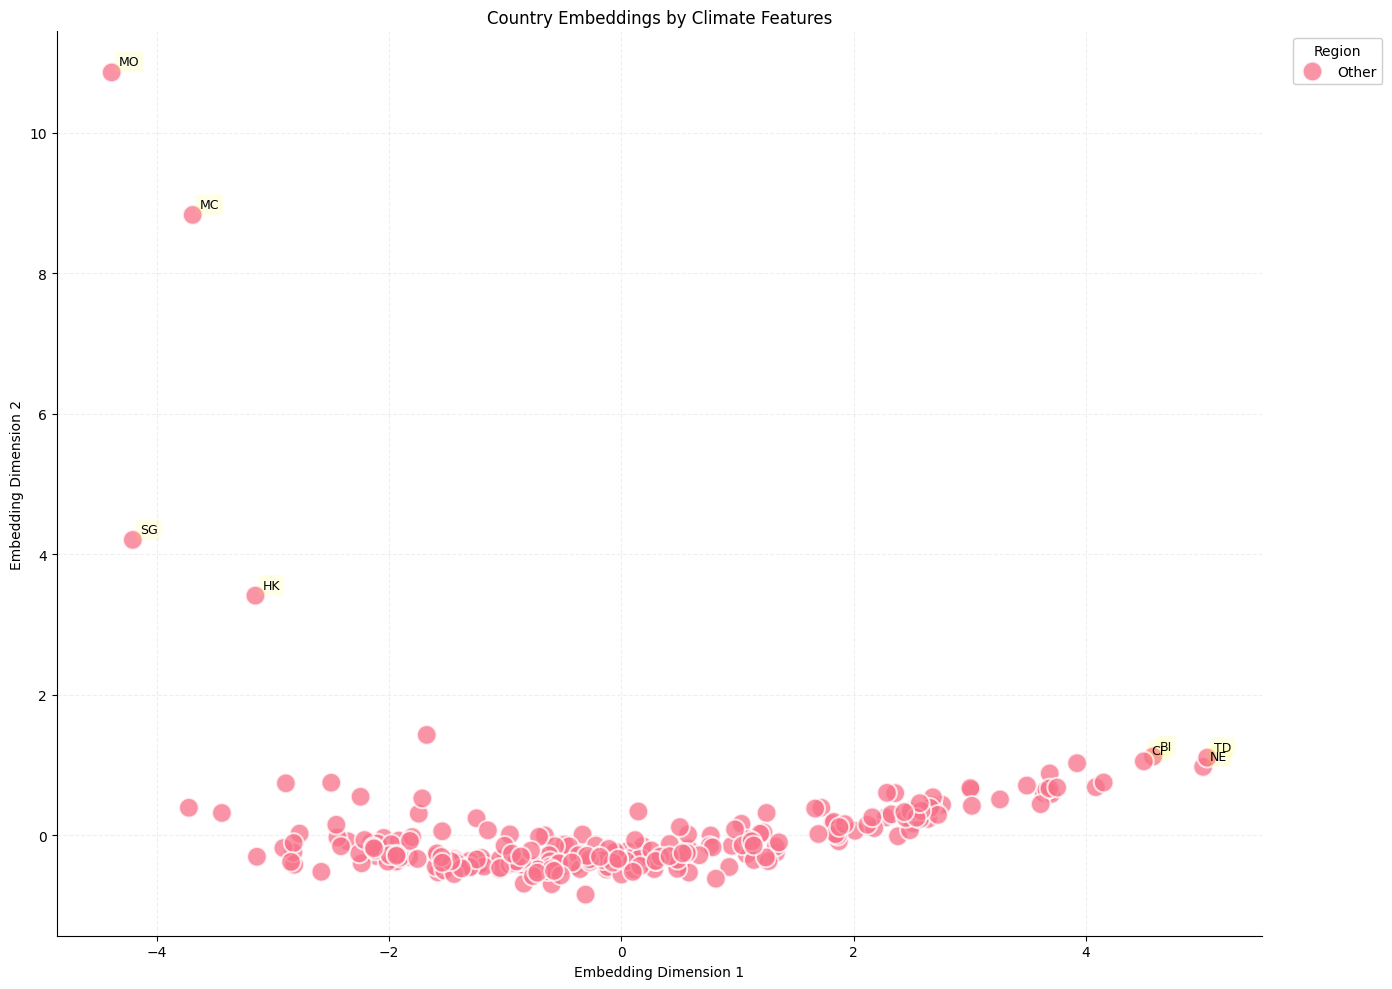

In [25]:
print("Building climate dataset...")
climate_data = build_climate_dataset()
print(f"Loaded {climate_data.shape[0]} countries x {climate_data.shape[1]} indicators")

embeddings = add_region_labels(compute_embeddings(climate_data, n_components=2))
plot_embeddings(embeddings, hue="region", title="Country Embeddings by Climate Features")

## Analysis: Determining Optimal Number of Components

To find the best number of PCA components, we analyze **explained variance ratio** — how much information each component preserves from the original data. We'll examine:
- **Individual variance**: How much each component contributes
- **Cumulative variance**: Total information captured by N components
- **Scree plot**: Visual representation to find the "elbow" point

In [26]:
print("Building climate dataset for variance analysis...")
X = SimpleImputer(strategy="median").fit_transform(build_climate_dataset())
X = StandardScaler().fit_transform(X)

pca_full = PCA(n_components=X.shape[1]).fit(X)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\n" + "=" * 60)
print("EXPLAINED VARIANCE ANALYSIS")
print("=" * 60)
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i}: {var*100:6.2f}% (cumulative: {cum_var*100:6.2f}%)")
for label, threshold in [("95%", 0.95), ("90%", 0.90), ("80%", 0.80)]:
    print(f"  {label} variance: {np.argmax(cumulative_variance >= threshold) + 1} component(s)")
print("=" * 60)

Building climate dataset for variance analysis...

EXPLAINED VARIANCE ANALYSIS
PC1:  57.67% (cumulative:  57.67%)
PC2:  16.81% (cumulative:  74.47%)
PC3:   9.54% (cumulative:  84.01%)
PC4:   6.51% (cumulative:  90.52%)
PC5:   4.90% (cumulative:  95.43%)
PC6:   4.57% (cumulative: 100.00%)
  95% variance: 5 component(s)
  90% variance: 4 component(s)
  80% variance: 3 component(s)


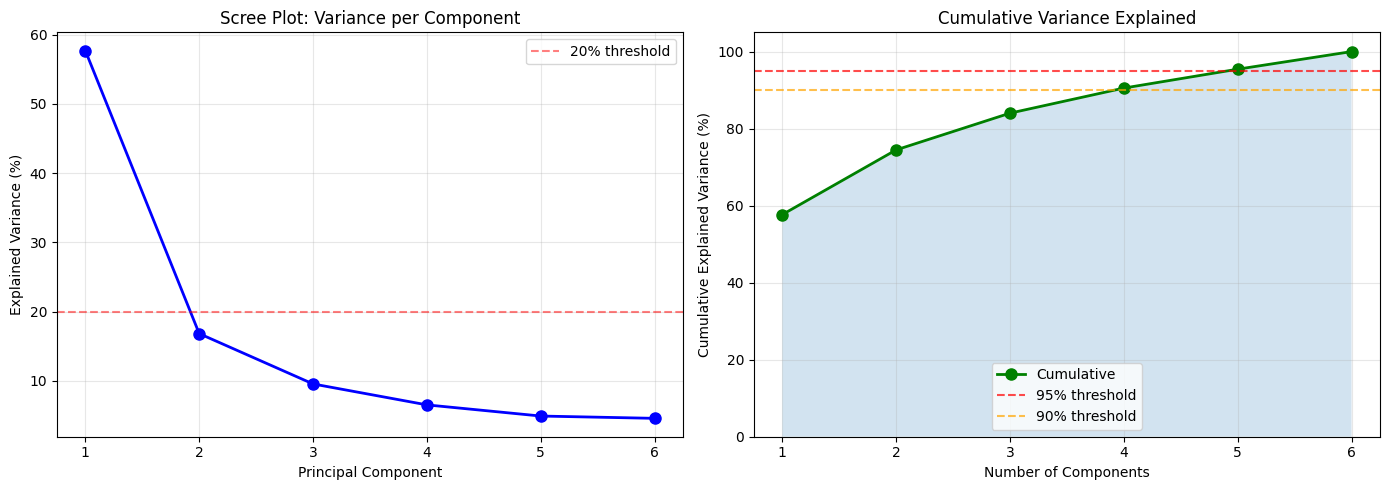

In [27]:
components = np.arange(1, len(explained_variance) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(components, explained_variance * 100, "bo-", linewidth=2, markersize=8)
ax1.axhline(20, color="r", linestyle="--", alpha=0.5, label="20% threshold")
ax1.set(title="Scree Plot: Variance per Component", xlabel="Principal Component", ylabel="Explained Variance (%)")
ax1.set_xticks(components)
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(components, cumulative_variance * 100, "go-", linewidth=2, markersize=8, label="Cumulative")
ax2.axhline(95, color="r", linestyle="--", alpha=0.7, label="95% threshold")
ax2.axhline(90, color="orange", linestyle="--", alpha=0.7, label="90% threshold")
ax2.fill_between(components, cumulative_variance * 100, alpha=0.2)
ax2.set(title="Cumulative Variance Explained", xlabel="Number of Components", ylabel="Cumulative Explained Variance (%)")
ax2.set_xticks(components)
ax2.set_ylim(0, 105)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Findings & Recommendations

**Your data (6 climate indicators):**
- **PC1** captures **57.67%** of variance — strong primary pattern in climate/economy
- **PC2** captures **16.81%** — secondary differentiator (good for 2D visualization!)  
- **PC3** captures **9.54%** — tertiary patterns

**How to choose:**

| Use case | Components | Variance | Tradeoff |
|----------|-----------|----------|----------|
| **Visualization** | 2 | 74.47% | Easy to plot, loses ~25% info |
| **Detailed analysis** | 3 | 84.01% | Good balance |
| **High fidelity** | 4 | 90.52% | Most detail without noise |
| **Maximum preservation** | 5+ | 95%+ | Diminishing returns |

**For this analysis:**
- **2 components (current)** is good for visualization because it captures the main patterns while fitting in 2D
- **3 components** would better preserve information if you plan to use embeddings for ML models
- **4+ components** adds minimal value (small incremental gains per component)

## Comparison: 2D vs 3D Embeddings

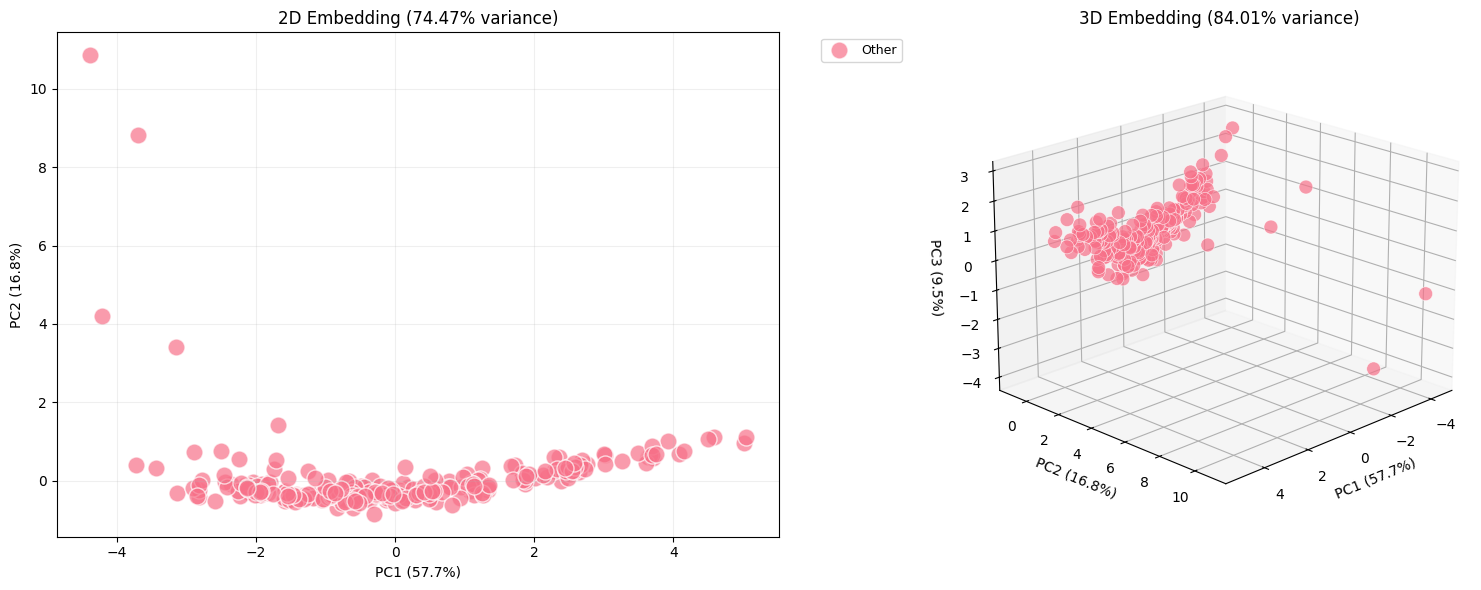

Saved embeddings to src/data/embeddings_iso3_3d.csv
            emb_0     emb_1     emb_2
country                              
1A       0.174424 -0.285807  0.034587
1W      -0.012361 -0.329130 -0.087382
4E      -0.148154 -0.347723 -0.459096
7E      -0.690641 -0.407795 -0.391256
8S       1.121288 -0.085484 -0.940301

2D: Captures 74.47% variance
3D: Captures 84.01% variance
Improvement: +9.54%


In [28]:
from mpl_toolkits.mplot3d import Axes3D
import os

climate_data = build_climate_dataset()
embeddings_2d = add_region_labels(compute_embeddings(climate_data, n_components=2))
embeddings_3d = add_region_labels(compute_embeddings(climate_data, n_components=3))
regions = sorted(embeddings_2d["region"].unique())
palette = sns.color_palette("husl", len(regions))

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121)
for region, color in zip(regions, palette):
    mask = embeddings_2d["region"].eq(region)
    ax1.scatter(
        embeddings_2d.loc[mask, "emb_0"],
        embeddings_2d.loc[mask, "emb_1"],
        s=150,
        alpha=0.7,
        edgecolor="white",
        linewidth=1,
        color=color,
        label=region,
    )
ax1.set(
    title=f"2D Embedding ({explained_variance[:2].sum()*100:.2f}% variance)",
    xlabel=f"PC1 ({explained_variance[0]*100:.1f}%)",
    ylabel=f"PC2 ({explained_variance[1]*100:.1f}%)",
)
ax1.grid(alpha=0.2)
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

ax2 = fig.add_subplot(122, projection="3d")
for region, color in zip(regions, palette):
    mask = embeddings_3d["region"].eq(region)
    ax2.scatter(
        embeddings_3d.loc[mask, "emb_0"],
        embeddings_3d.loc[mask, "emb_1"],
        embeddings_3d.loc[mask, "emb_2"],
        s=100,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
        color=color,
        label=region,
    )
ax2.set(
    title=f"3D Embedding ({explained_variance[:3].sum()*100:.2f}% variance)",
    xlabel=f"PC1 ({explained_variance[0]*100:.1f}%)",
    ylabel=f"PC2 ({explained_variance[1]*100:.1f}%)",
    zlabel=f"PC3 ({explained_variance[2]*100:.1f}%)",
)
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

embeddings_3d[["emb_0", "emb_1", "emb_2"]].to_csv("src/data/embeddings_iso3_3d.csv")
print("Saved embeddings to src/data/embeddings_iso3_3d.csv")
print(embeddings_3d[["emb_0", "emb_1", "emb_2"]].head())
print(f"\n2D: Captures {explained_variance[:2].sum()*100:.2f}% variance")
print(f"3D: Captures {explained_variance[:3].sum()*100:.2f}% variance")
print(f"Improvement: +{explained_variance[2]*100:.2f}%")

In [29]:
import os
import pandas as pd
import pycountry
import requests

countries = requests.get("https://api.worldbank.org/v2/country?format=json&per_page=400").json()[1]
wb_map = {country["id"]: country for country in countries}


def wb_id_to_iso3(wb_id):
    if pd.isna(wb_id):
        return None

    wb_id = str(wb_id).strip()
    country = wb_map.get(wb_id)
    if country and country.get("iso2Code"):
        match = pycountry.countries.get(alpha_2=country["iso2Code"].upper())
        if match:
            return match.alpha_3

    for country in countries:
        if country.get("name", "").lower() == wb_id.lower() and country.get("iso2Code"):
            match = pycountry.countries.get(alpha_2=country["iso2Code"].upper())
            if match:
                return match.alpha_3

    try:
        return pycountry.countries.search_fuzzy(wb_id)[0].alpha_3
    except Exception:
        return None


emb = pd.read_csv("src/data/embeddings_iso3_3d.csv", index_col=0).rename_axis("wb_id").reset_index()
emb["iso3_mapped"] = emb["wb_id"].map(wb_id_to_iso3)

mapped = emb.dropna(subset=["iso3_mapped"]).set_index("iso3_mapped")[["emb_0", "emb_1", "emb_2"]]
if mapped.empty:
    print("No mappings found. The saved embeddings may use aggregate World Bank IDs.")
else:
    out_csv = "src/data/embeddings_iso3_3d_mapped.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    mapped.to_csv(out_csv)
    print(f"Saved mapped embeddings to {out_csv}")
    print(mapped.head())

Saved mapped embeddings to src/data/embeddings_iso3_3d_mapped.csv
                emb_0     emb_1     emb_2
iso3_mapped                              
AND         -2.155526 -0.099045  1.090775
ARE         -2.354902 -0.086402  1.196469
AFG          2.381075 -0.013857 -0.791427
ATG         -0.600651 -0.696483 -1.296734
ALB          0.138654 -0.234058 -0.686938
